In [1]:
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.Data.psf import PSF

In [2]:
from astropy.cosmology import wCDM
from astropy import units as u

Om = 0.3
w = -1
custom_cosmo = wCDM(H0=70 * u.km / u.s / u.Mpc, Om0=Om, Ob0=0.05, Ode0=1-Om, w0=w)

z_l = 0.5
z_s = 1.5

In [3]:
import numpy as np
from copy import deepcopy

from matplotlib import pyplot as plt

def compute_extended_magnification(kwargs_params,
                                   kwargs_model,
                                   kwargs_psf,
                                   kwargs_data,
                                   kwargs_numerics,
                                   z_lens,
                                   z_source,
                                   cosmology=None,
                                   component_index=None,
                                   mask=None,
                                   verbose=False):
    """
    Compute extended-source magnification(s) for lenstronomy sources.

    Parameters
    ----------
    kwargs_params : dict
        lenstronomy-style kwargs dict with 'kwargs_lens', 'kwargs_source', 'kwargs_lens_light' entries.
    kwargs_model : dict
        lenstronomy-style model dict with 'lens_model_list', 'source_model_list', 'lens_light_model_list'.
    kwargs_psf : kwargs or None
        PSF kwargs passed to image_model.image(...)
    kwargs_data : dict
        lenstronomy-style data kwargs dict with 'image_data', 'sigma_data', 'background_rms', etc.
    component_index : int or None
        If None, compute magnification for the *combined* source (all components together).
        If an integer >=0, compute magnification only for that source component (others zeroed).
    mask : 2D boolean array or None
        Optional mask (True = keep pixel, False = ignore). Applied identically to lensed/unlensed.
    verbose : bool
        If True prints intermediate checks.

    Returns
    -------
    mu : float or list of floats
        Magnification ratio(s). If component_index is None and multiple components provided,
        returns single float for the combined source. If component_index is an int, returns float
        for that component. You can also call repeatedly for different components.

    Notes
    -----
    - image_model must be configured with the same image settings you will use for simulations.
    - Ensure the image stamp is large enough to capture all lensed flux.
    - This uses simple pixel-sum flux measurement. For noisy sims you might prefer aperture or fitted total flux.
    """
    if cosmology is None:
        from astropy.cosmology import wCDM
        from astropy import units as u

        Om = 0.3
        w = -1
        cosmology = wCDM(H0=70 * u.km / u.s / u.Mpc, Om0=Om, Ob0=0.05, Ode0=1-Om, w0=w)

    # Defensive copies
    kwargs_model_local = deepcopy(kwargs_model)
    kwargs_params_local = deepcopy(kwargs_params)

    # remove lens light from kwargs_model_local and kwargs_params_local
    kwargs_model_local['lens_light_model_list'] = []
    kwargs_params_local['kwargs_lens_light'] = []

    # create a local copy of kwargs without lens mass for unlensed render
    kwargs_params_local_no_lens = deepcopy(kwargs_params_local)
    kwargs_params_local_no_lens['kwargs_lens'] = []

    # function to sum flux with mask
    def _sum_flux(img, mask_local):
        if mask_local is None:
            return np.sum(img)
        # keep pixels where mask == True
        return np.sum(img[mask_local])

    # create image models
    from lenstronomy.ImSim.image_model import ImageModel
    from lenstronomy.Data.imaging_data import ImageData
    from lenstronomy.LensModel.lens_model import LensModel
    from lenstronomy.LightModel.light_model import LightModel
    from lenstronomy.Data.psf import PSF

    data_class_lensed = ImageData(**kwargs_data)
    data_class_unlensed = ImageData(**kwargs_data)  # same data settings for unlensed

    lens_model = LensModel(kwargs_model_local['lens_model_list'], lens_redshift_list=[z_lens for _ in range(len(kwargs_model_local['lens_model_list']))], cosmo=cosmology)
    light_model = LightModel(kwargs_model_local['source_model_list'], source_redshift_list=[z_source for _ in range(len(kwargs_model_local['source_model_list']))])

    psf_class = PSF(**kwargs_psf)

    image_model_lensed = ImageModel(data_class_lensed, psf_class, source_model_class=light_model, lens_model_class=lens_model, kwargs_numerics=kwargs_numerics)
    image_model_unlensed = ImageModel(data_class_unlensed, psf_class, source_model_class=light_model, kwargs_numerics=kwargs_numerics)

    '''  # set all source amps to 1.0 (unit-normalized template)
    for s in kwargs_params_local['kwargs_source']:
        s['amp'] = 1.0

    for s in kwargs_params_local_no_lens['kwargs_source']:
        s['amp'] = 1.0'''
    
    img_lensed = image_model_lensed.image(kwargs_params_local['kwargs_lens'], kwargs_params_local['kwargs_source'], kwargs_lens_light=None, kwargs_ps=None)
    img_unlensed = image_model_unlensed.image(None, kwargs_params_local_no_lens['kwargs_source'], kwargs_lens_light=None, kwargs_ps=None)

    F_lensed = _sum_flux(img_lensed, mask)
    F_unlensed = _sum_flux(img_unlensed, mask)

    if verbose:
        import matplotlib.pyplot as plt
        print("F_lensed:", F_lensed, "F_unlensed:", F_unlensed)

        vmin, vmax = np.min([np.max(img_lensed), np.max(img_unlensed)]) - 2, np.max([np.max(img_lensed), np.max(img_unlensed)])

        extent = (-0.5*kwargs_data['image_data'].shape[1]*kwargs_data['transform_pix2angle'][0][0],
                  0.5*kwargs_data['image_data'].shape[1]*kwargs_data['transform_pix2angle'][0][0],
                  -0.5*kwargs_data['image_data'].shape[0]*kwargs_data['transform_pix2angle'][1][1],
                  0.5*kwargs_data['image_data'].shape[0]*kwargs_data['transform_pix2angle'][1][1])
        
        _, axes = plt.subplots(1,2, figsize=(12,6))
        ax = axes[0]
        ax.imshow(np.log10(img_lensed), origin='lower', cmap='gray', extent=extent, vmin=-5)
        plt.colorbar(ax=ax, mappable=ax.images[0])
        ax.set_title("Lensed")
        ax = axes[1]
        ax.imshow(np.log10(img_unlensed), origin='lower', cmap='gray', extent=extent, vmin=-5)
        plt.colorbar(ax=ax, mappable=ax.images[0])
        ax.set_title("Unlensed")
        plt.show()  

    if F_unlensed == 0:
        raise ValueError("Unlensed flux is zero -> check source template or pixel sampling.")
    mu = F_lensed / F_unlensed

    return mu



In [12]:
lens_size_actual = 1 * u.kpc
source_size_actual = 0.5 * u.kpc
print(((lens_size_actual / custom_cosmo.angular_diameter_distance(z_l)).decompose() * u.rad).to(u.arcsec), ((source_size_actual / custom_cosmo.angular_diameter_distance(z_s)).decompose() * u.rad).to(u.arcsec))
lens_kwargs = [{'theta_E': 1.8,
   'center_x': 0.3686891993185043,
   'center_y': -0.040460506267520104,
   'e1': -0.1,
   'e2': 0.2},
   {'theta_E': 0.4,
    'center_x': 0.3686891993185043,
    'center_y': -0.040460506267520104
    }]
source_kwargs = [{'amp': 9.78,
   'R_sersic': 0.2,#((source_size_actual / custom_cosmo.angular_diameter_distance(z_s)).decompose() * u.rad).to(u.arcsec).value,
   'n_sersic': 1,
   'e1': -0.1,
   'e2': -0.7,
   'center_x': 0.25,
   'center_y': 0.15}]
lens_light_kwargs = [{'amp': 1.0, 'R_sersic': 2.5,#((lens_size_actual / custom_cosmo.angular_diameter_distance(z_l)).decompose() * u.rad).to(u.arcsec).value, 
                      'n_sersic': 4, 'center_x': 0.3686891993185043, 'center_y': -0.040460506267520104, 'e1': -0.1, 'e2': 0.2,}]

kwargs_params = {
    'kwargs_lens': lens_kwargs,
    'kwargs_source': source_kwargs,
    'kwargs_lens_light': lens_light_kwargs
}

lens_model_list = ['SIE', 'POINT_MASS']
source_model_list = ['SERSIC_ELLIPSE']
lens_light_model_list = ['SERSIC_ELLIPSE']

kwargs_model = {
    'lens_model_list': lens_model_list,
    'source_model_list': source_model_list,
    'lens_light_model_list': lens_light_model_list
}

n_axis = 1000
pixel_scale = 0.1  # arcsec/pixel

kwargs_data = {
    'background_rms': 0.004,  # rms of background noise
    'exposure_time': 500,  # exposure time (or a map per pixel)
    'ra_at_xy_0': -n_axis * pixel_scale / 2,  # RA at (0,0) pixel
    'dec_at_xy_0': -n_axis * pixel_scale / 2,  # DEC at (0,0) pixel
    'transform_pix2angle': np.array([[pixel_scale, 0], [0, pixel_scale]]),  # matrix to translate shift in pixel in shift in relative RA/DEC (2x2 matrix). Make sure it's units are arcseconds or the angular units you want to model.
    'image_data': np.zeros((n_axis, n_axis))
}
kwargs_psf = {
    'psf_type': 'GAUSSIAN',
    'fwhm': 0.1,  # FWHM in arcseconds
    'pixel_size': pixel_scale,  # pixel size in arcseconds
    'truncation': 3  # size of the PSF kernel in sigma
}
kwargs_numerics = {
    'supersampling_factor': 2,  # supersampling factor for image simulation
    'supersampling_convolution': True  # supersampling convolution for image simulation
}



0.16382137507884803 arcsec 0.05908330192851481 arcsec


F_lensed: 52.370229515130404 F_unlensed: 4.689965818377932


/var/folders/0k/nyc58v7d4vzg86yfwjhxcz2m0000gn/T/ipykernel_53693/3763396699.py:122: RuntimeWarning: divide by zero encountered in log10
  ax.imshow(np.log10(img_lensed), origin='lower', cmap='gray', extent=extent, vmin=-5)
/var/folders/0k/nyc58v7d4vzg86yfwjhxcz2m0000gn/T/ipykernel_53693/3763396699.py:126: RuntimeWarning: divide by zero encountered in log10
  ax.imshow(np.log10(img_unlensed), origin='lower', cmap='gray', extent=extent, vmin=-5)


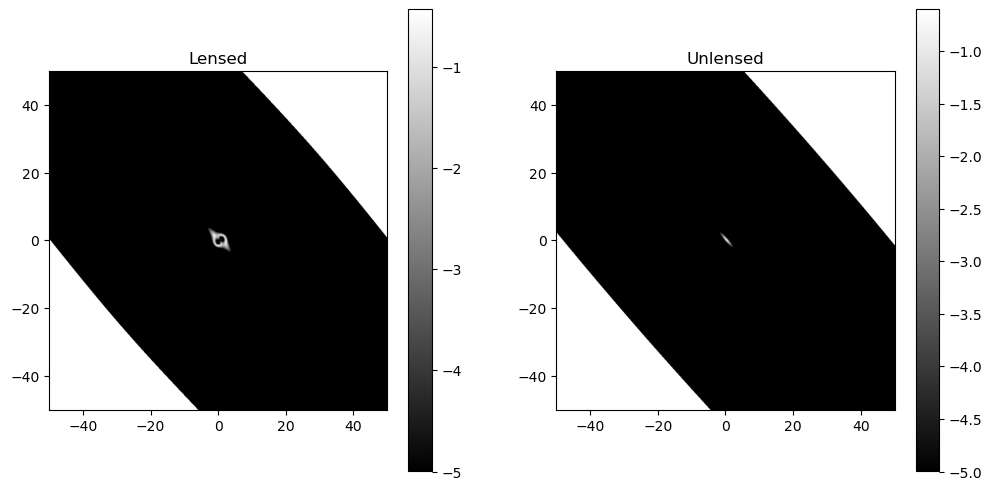

11.16644162094195

In [13]:
mu = compute_extended_magnification(kwargs_params,
                                   kwargs_model,
                                   kwargs_psf,
                                   kwargs_data,
                                   kwargs_numerics,
                                   z_lens=0.5,
                                   z_source=2.0,
                                   verbose=True)
mu

In [14]:
# compute ratio of flux of source and lens light from simulated images
def compute_flux_ratio(kwargs_params,
                                   kwargs_model,
                                   kwargs_psf,
                                   kwargs_data,
                                   kwargs_numerics,
                                   z_lens,
                                   z_source,
                                   cosmology=None,
                                   verbose=False):
    if cosmology is None:
        from astropy.cosmology import wCDM
        from astropy import units as u

        Om = 0.3
        w = -1
        cosmology = wCDM(H0=70 * u.km / u.s / u.Mpc, Om0=Om, Ob0=0.05, Ode0=1-Om, w0=w)

    # Defensive copies
    kwargs_model_source = deepcopy(kwargs_model)
    kwargs_params_source = deepcopy(kwargs_params)
    kwargs_model_lens = deepcopy(kwargs_model)
    kwargs_params_lens = deepcopy(kwargs_params)

    # remove lens light from source kwargs
    kwargs_model_source['lens_light_model_list'] = []
    kwargs_params_source['kwargs_lens_light'] = []

    # change source light amplitude to zero in lens kwargs
    kwargs_params_lens['kwargs_source'][0]['amp'] = 0.0
    if verbose:
        print(kwargs_params_lens['kwargs_lens_light'])

        print(kwargs_params_source)
        print(kwargs_params_lens)

    # create image models
    from lenstronomy.ImSim.image_model import ImageModel
    from lenstronomy.Data.imaging_data import ImageData
    from lenstronomy.LensModel.lens_model import LensModel
    from lenstronomy.LightModel.light_model import LightModel
    from lenstronomy.Data.psf import PSF

    data_class_source = ImageData(**kwargs_data)
    data_class_lens = ImageData(**kwargs_data)  # same data settings for unlensed

    lens_model = LensModel(kwargs_model_lens['lens_model_list'], lens_redshift_list=[z_lens for _ in range(len(kwargs_model_lens['lens_model_list']))], cosmo=cosmology)
    light_model_source = LightModel(kwargs_model_source['source_model_list'], source_redshift_list=[z_source for _ in range(len(kwargs_model_source['source_model_list']))])
    light_model_lens = LightModel(kwargs_model_lens['lens_light_model_list'], source_redshift_list=[z_lens for _ in range(len(kwargs_model_lens['lens_light_model_list']))])

    psf_class = PSF(**kwargs_psf)

    image_model_source = ImageModel(data_class_source, psf_class, source_model_class=light_model_source, lens_model_class=lens_model, kwargs_numerics=kwargs_numerics)
    image_model_lens = ImageModel(data_class_lens, psf_class, lens_light_model_class=light_model_lens, lens_model_class=lens_model, kwargs_numerics=kwargs_numerics)

    img_source = image_model_source.image(kwargs_lens=kwargs_params_source['kwargs_lens'], kwargs_source=kwargs_params_source['kwargs_source'], unconvolved=True)
    img_lens = image_model_lens.image(kwargs_lens=kwargs_params_lens['kwargs_lens'], kwargs_lens_light=kwargs_params_lens['kwargs_lens_light'], unconvolved=True)

    if np.sum(img_lens) == 0:
        raise ValueError("Lens image has zero flux -> check lens light template or pixel sampling.")
    print(np.sum(img_source), np.sum(img_lens))
    ratio =  np.sum(img_lens) /np.sum(img_source)

    return ratio, img_source, img_lens

In [15]:
ratio, source, lens = compute_flux_ratio(kwargs_params,
                                   kwargs_model,
                                   kwargs_psf,
                                   kwargs_data,
                                    kwargs_numerics,
                                   z_lens=z_l,
                                   z_source=z_s)
ratio

52.3702295151304 140.62126556699138


2.6851374696833092

In [8]:
'''luminosity_distance_lens = custom_cosmo.luminosity_distance(z_l).to(u.cm).value
luminosity_distance_source = custom_cosmo.luminosity_distance(z_s).to(u.cm).value

kwargs_params['kwargs_source'][0]['amp'] = 1 / luminosity_distance_source
kwargs_params['kwargs_lens_light'][0]['amp'] = 1 / luminosity_distance_lens
ratio_luminosity_distance, source, lens = compute_flux_ratio(kwargs_params,
                                   kwargs_model,
                                   kwargs_psf,
                                   kwargs_data,
                                   z_lens=z_l,
                                   z_source=z_s,
                                   )
ratio_luminosity_distance, (kwargs_params['kwargs_source'][0]['amp'] /  kwargs_params['kwargs_lens_light'][0]['amp'])**-1'''

"luminosity_distance_lens = custom_cosmo.luminosity_distance(z_l).to(u.cm).value\nluminosity_distance_source = custom_cosmo.luminosity_distance(z_s).to(u.cm).value\n\nkwargs_params['kwargs_source'][0]['amp'] = 1 / luminosity_distance_source\nkwargs_params['kwargs_lens_light'][0]['amp'] = 1 / luminosity_distance_lens\nratio_luminosity_distance, source, lens = compute_flux_ratio(kwargs_params,\n                                   kwargs_model,\n                                   kwargs_psf,\n                                   kwargs_data,\n                                   z_lens=z_l,\n                                   z_source=z_s,\n                                   )\nratio_luminosity_distance, (kwargs_params['kwargs_source'][0]['amp'] /  kwargs_params['kwargs_lens_light'][0]['amp'])**-1"

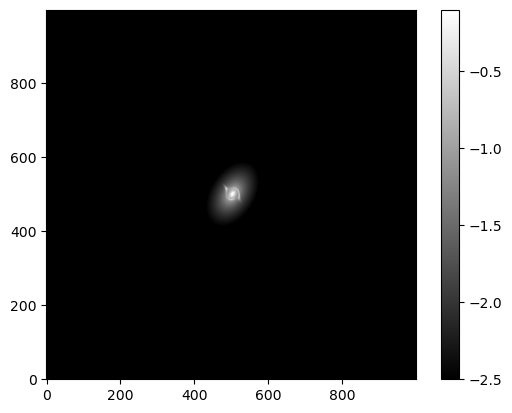

In [9]:
plt.imshow(np.log10(source + lens), origin='lower', cmap='gray', vmin=-2.5, vmax=-0.1)
plt.colorbar()
plt.show()

/var/folders/0k/nyc58v7d4vzg86yfwjhxcz2m0000gn/T/ipykernel_53693/3780988563.py:7: RuntimeWarning: divide by zero encountered in log10
  ax.imshow(np.log10(source), origin='lower', cmap='gray', vmin=-3.5)


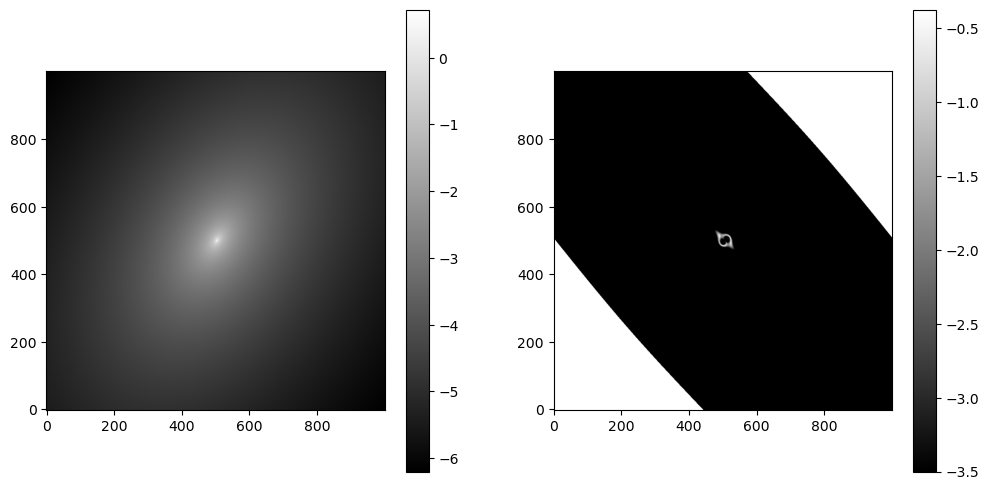

In [10]:
fig, axes = plt.subplots(1,2, figsize=(12,6))

ax = axes[0]
ax.imshow(np.log10(lens), origin='lower', cmap='gray')
plt.colorbar(mappable=ax.images[0], ax=ax)
ax = axes[1]
ax.imshow(np.log10(source), origin='lower', cmap='gray', vmin=-3.5)
plt.colorbar(mappable=ax.images[0], ax=ax)
plt.show()

In [11]:
ratio_luminosity_distance / ratio, mu

NameError: name 'ratio_luminosity_distance' is not defined

In [ ]:
def update_params_for_redshift(kwargs_params, z_l, z_s, cosmology, lens_size_actual=1 * u.kpc, source_size_actual=0.5 * u.kpc, vary_sizes=True):
    kwargs_params_updated = deepcopy(kwargs_params)

    if vary_sizes:
        kwargs_params_updated['kwargs_source'][0]['R_sersic'] = ((source_size_actual / cosmology.angular_diameter_distance(z_s)).decompose() * u.rad).to(u.arcsec).value
        kwargs_params_updated['kwargs_lens_light'][0]['R_sersic'] = ((lens_size_actual / cosmology.angular_diameter_distance(z_l)).decompose() * u.rad).to(u.arcsec).value

    luminosity_distance_lens = cosmology.luminosity_distance(z_l).to(u.cm).value
    luminosity_distance_source = cosmology.luminosity_distance(z_s).to(u.cm).value

    kwargs_params_updated['kwargs_source'][0]['amp'] = 1 / luminosity_distance_source**2
    kwargs_params_updated['kwargs_lens_light'][0]['amp'] = 1 / luminosity_distance_lens**2

    return kwargs_params_updated

In [ ]:
ratios_source_redshift_w_size = []
ratios_source_redshift_wout_size = []
ratios_constant_redshift = []
luminosity_distance_sources = []
source_angular_sizes = []
redshifts = np.linspace(0.5, 2.5, 20)
for _z_s in redshifts:
    luminosity_distance_source = custom_cosmo.luminosity_distance(_z_s).to(u.cm).value
    ratio, _, _ = compute_flux_ratio(update_params_for_redshift(kwargs_params, z_l, _z_s, custom_cosmo, lens_size_actual, source_size_actual),
                                       kwargs_model,
                                       kwargs_psf,
                                       kwargs_data,
                                       kwargs_numerics,
                                       z_lens=z_l,
                                       z_source=_z_s,
                                       )
    ratios_source_redshift_w_size.append(ratio)
    ratio, _, _ = compute_flux_ratio(update_params_for_redshift(kwargs_params, z_l, _z_s, custom_cosmo, lens_size_actual, source_size_actual, vary_sizes=False),
                                       kwargs_model,
                                       kwargs_psf,
                                       kwargs_data,
                                       kwargs_numerics,
                                       z_lens=z_l,
                                       z_source=_z_s,
                                       )
    ratios_source_redshift_wout_size.append(ratio)
    ratio, _, _ = compute_flux_ratio(kwargs_params,
                                       kwargs_model,
                                       kwargs_psf,
                                       kwargs_data,
                                       kwargs_numerics,
                                       z_lens=z_l,
                                       z_source=_z_s,
                                       )
    ratios_constant_redshift.append(ratio)
    luminosity_distance_sources.append(luminosity_distance_source)
    source_angular_size = ((source_size_actual / custom_cosmo.angular_diameter_distance(_z_s)).decompose() * u.rad).to(u.arcsec).value
    source_angular_sizes.append(source_angular_size)

ratios_source_redshift_w_size = np.array(ratios_source_redshift_w_size)
ratios_source_redshift_wout_size = np.array(ratios_source_redshift_wout_size)
ratios_constant_redshift = np.array(ratios_constant_redshift)

1.4602488173719008e-56 8.102783136943904e-57
7.014622398065441e-56 1.7604967594575274e-54
509.2173142425142 1285.659351264038
7.781969495677046e-57 8.102783136943904e-57
4.422552581932098e-56 1.7604967594575274e-54
509.2173142425142 1285.659351264038
4.664338632323913e-57 8.102783136943904e-57
2.9912764458595557e-56 1.7604967594575274e-54
509.2173142425142 1285.659351264038
3.0419233901477335e-57 8.102783136943904e-57
2.1309237935442244e-56 1.7604967594575274e-54
509.2173142425142 1285.659351264038
2.1135963114986905e-57 8.102783136943904e-57
1.5799082539785543e-56 1.7604967594575274e-54
509.2173142425142 1285.659351264038
1.5425409746988927e-57 8.102783136943904e-57
1.2091677099124378e-56 1.7604967594575274e-54
509.2173142425142 1285.659351264038
1.1706486455338803e-57 8.102783136943904e-57
9.496590291565517e-57 1.7604967594575274e-54
509.2173142425142 1285.659351264038
9.170504573224824e-58 8.102783136943904e-57
7.620160161181045e-57 1.7604967594575274e-54
509.2173142425142 1285.6593

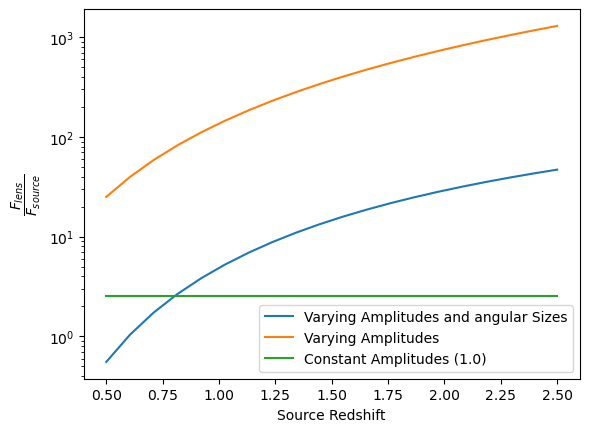

In [ ]:
plt.plot(redshifts, ratios_source_redshift_w_size, label='Varying Amplitudes and angular Sizes')
plt.plot(redshifts, ratios_source_redshift_wout_size, label='Varying Amplitudes')
plt.plot(redshifts, ratios_constant_redshift, label='Constant Amplitudes (1.0)')
plt.yscale('log')
plt.xlabel('Source Redshift')
plt.ylabel(r'$\dfrac{F_{lens}}{F_{source}}$')
plt.legend()
plt.show()

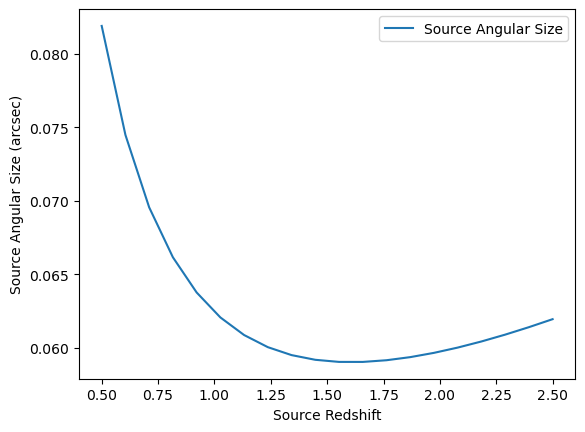

In [ ]:
plt.plot(redshifts, source_angular_sizes, label='Source Angular Size')
plt.xlabel('Source Redshift')
plt.ylabel('Source Angular Size (arcsec)')
plt.legend()
plt.show()

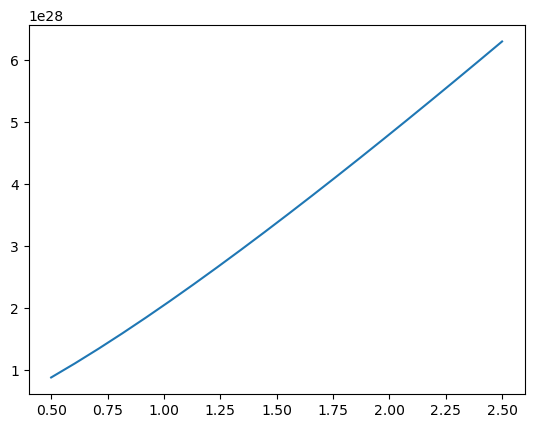

In [ ]:
plt.plot(redshifts, luminosity_distance_sources)

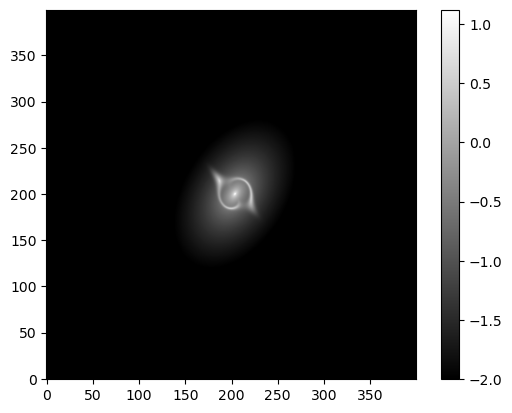

In [ ]:
from matplotlib import pyplot as plt

plt.imshow(np.log10(lens + source), origin='lower', cmap='grey', vmin=-2)
plt.colorbar()
plt.show()

4.556154916906705 1285.659351264038
4.612577888013909 1285.659351264038
4.669000859121112 1285.659351264038
4.725423830228317 1285.659351264038
4.7818468013355195 1285.659351264038
4.838269772442724 1285.659351264038
4.8946927435499274 1285.659351264038
4.951115714657132 1285.659351264038
5.007538685764337 1285.659351264038
5.063961656871539 1285.659351264038
5.120384627978743 1285.659351264038
5.176807599085947 1285.659351264038
5.233230570193151 1285.659351264038
5.289653541300354 1285.659351264038
5.346076512407559 1285.659351264038
5.402499483514764 1285.659351264038
5.458922454621966 1285.659351264038
5.51534542572917 1285.659351264038
5.571768396836373 1285.659351264038
5.628191367943577 1285.659351264038


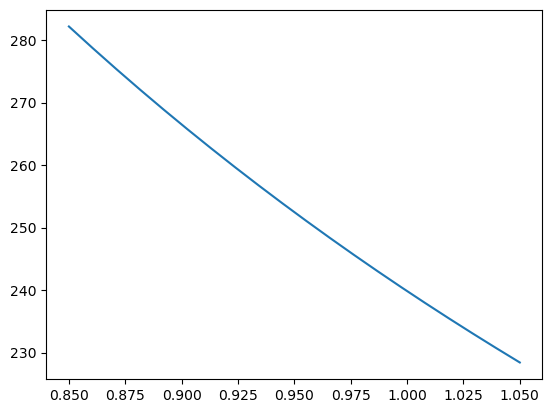

In [ ]:
source_amps = np.linspace(0.85, 1.05, 20)
ratios = []
for s_amp in source_amps:
    kwargs_params['kwargs_source'][0]['amp'] = s_amp
    ratio, source, lens = compute_flux_ratio(kwargs_params,
                                       kwargs_model,
                                       kwargs_psf,
                                       kwargs_data,
                                       kwargs_numerics,
                                       z_lens=0.5,
                                       z_source=2.0,
                                       )
    ratios.append(ratio)
ratios = np.array(ratios)
plt.plot(source_amps, ratios)

In [ ]:
def compute_fluxes(kwargs_params,
                    kwargs_model,
                    kwargs_data,
                    kwargs_psf,
                    kwargs_numerics,
                    z_lens,
                    z_source,
                    cosmology=None,
                    verbose=False,
                    num_pixes=None,
                    lens_image=True):
    if cosmology is None:
        from astropy.cosmology import FlatLambdaCDM
        from astropy import units as u

        Om = 0.3
        cosmology = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Om0=Om, Ob0=0.05)

    # Defensive copies
    _kwargs_data = deepcopy(kwargs_data)

    psf_model_class = PSF(**kwargs_psf)

    # create image models
    lens_model_class = LensModel(kwargs_model['lens_model_list'], lens_redshift_list=[z_lens for _ in range(len(kwargs_model['lens_model_list']))], cosmo=cosmology)
    source_model_class = LightModel(kwargs_model['source_model_list'], source_redshift_list=[z_source for _ in range(len(kwargs_model['source_model_list']))])

    if num_pixes is None:
        num_pixes = np.linspace(100, 400, 20, dtype=int)

    total_source_fluxes = []

    for n_pix in num_pixes:
        _kwargs_data['image_data'] = np.zeros((n_pix, n_pix))
        _kwargs_data['ra_at_xy_0'] = -n_pix * kwargs_data['transform_pix2angle'][0][0] / 2  # RA at (0,0) pixel
        _kwargs_data['dec_at_xy_0'] = -n_pix * kwargs_data['transform_pix2angle'][1][1] / 2  # Dec at (0,0) pixel
        image_model = ImageModel(lens_light_model_class=source_model_class, lens_model_class=lens_model_class, data_class=ImageData(**_kwargs_data), psf_class=psf_model_class, kwargs_numerics=kwargs_numerics)
        total_source_fluxes.append(np.sum(image_model.image(kwargs_lens=kwargs_params['kwargs_lens'], kwargs_lens_light=kwargs_params['kwargs_source'], unconvolved=True)))
        if verbose:
            plt.imshow(image_model.image(kwargs_lens=kwargs_params['kwargs_lens'], kwargs_source=kwargs_params['kwargs_lens_light'], unconvolved=True), origin='lower', cmap='gray')
            plt.colorbar()
            plt.show()
    return num_pixes, total_source_fluxes


In [ ]:
kwargs_numerics['supersampling_factor'] = 2
kwargs_numerics['supersampling_convolution'] = True
runs = 1

In [ ]:
xs = np.tile(np.linspace(50, 450, 30, dtype=int), (runs, 1))
ys = []
for i in range(runs):
    _, y = compute_fluxes(kwargs_params, kwargs_model, kwargs_data, kwargs_psf, kwargs_numerics, z_l, z_s, 
                      custom_cosmo, num_pixes=xs[i])
    ys.append(y)

In [ ]:
mean_diff_4 = np.mean(np.abs(np.diff(ys)), axis=0)
std_diff_4 = np.std(np.abs(np.diff(ys)), axis=0)

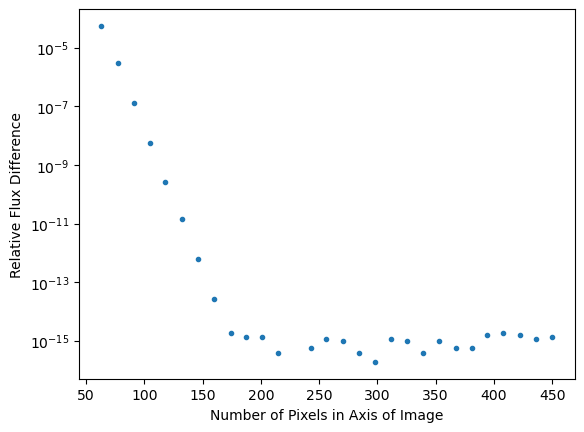

In [ ]:
plt.errorbar(xs[0, 1:], mean_diff_4 / np.array(ys)[0, 1:], yerr=std_diff_4, fmt='.')

plt.yscale('log')
#plt.ylim(1e-3, 1e-1)

plt.ylabel('Relative Flux Difference')
plt.xlabel('Number of Pixels in Axis of Image')
plt.show()

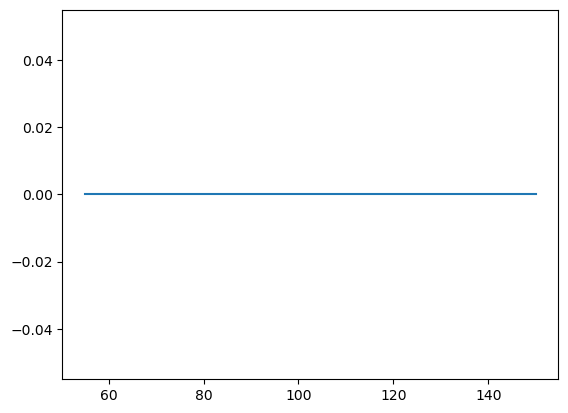

In [ ]:
plt.plot(xs[0, 1:], std_diff)
plt.show()